In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D, Dropout, Flatten, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import optimizers

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
print("Train Data Shape:", X_train_full.shape)
print("Test Data Shape:", X_test.shape)

Train Data Shape: (60000, 28, 28)
Test Data Shape: (10000, 28, 28)


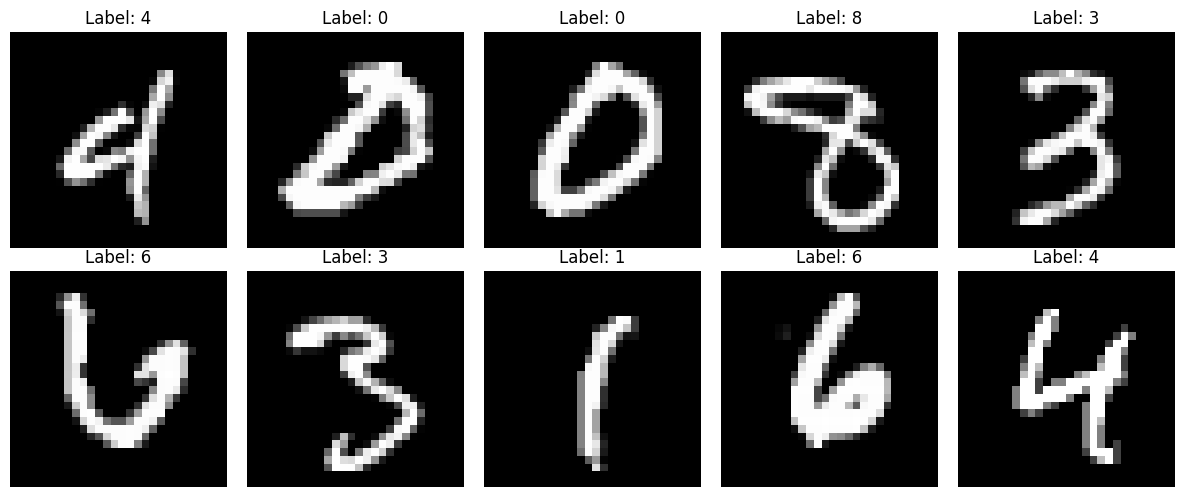

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, X_train_full.shape[0])
    ax.imshow(X_train_full[idx], cmap='gray')
    ax.axis('off')
    ax.set_title(f"Label: {y_train_full[idx]}")
plt.tight_layout()
plt.show()

In [4]:
X_train, X_cv, y_train, y_cv = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=1212)

In [5]:
X_train = np.expand_dims(X_train, axis=-1).astype('float32') / 255.0
X_cv = np.expand_dims(X_cv, axis=-1).astype('float32') / 255.0
X_test_processed = np.expand_dims(X_test, axis=-1).astype('float32') / 255.0

num_digits = 10
y_train_cat = tf.keras.utils.to_categorical(y_train, num_digits)
y_cv_cat = tf.keras.utils.to_categorical(y_cv, num_digits)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_digits)

print("X_train shape:", X_train.shape)
print("X_cv shape:", X_cv.shape)
print("X_test shape:", X_test_processed.shape)

X_train shape: (48000, 28, 28, 1)
X_cv shape: (12000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)


In [6]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    fill_mode='constant',
    cval=0
)
datagen.fit(X_train)

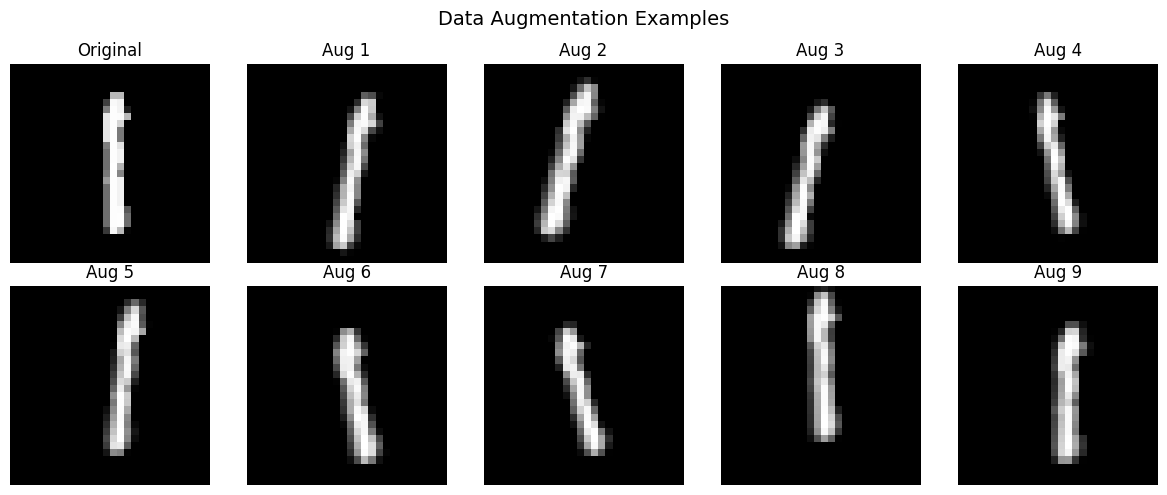

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
sample_img = X_train[0:1]
aug_iter = datagen.flow(sample_img, batch_size=1)
axes[0, 0].imshow(sample_img[0].reshape(28, 28), cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')
for i, ax in enumerate(axes.flat[1:]):
    aug_img = next(aug_iter)[0]
    ax.imshow(aug_img.reshape(28, 28), cmap='gray')
    ax.set_title(f'Aug {i+1}')
    ax.axis('off')
plt.suptitle('Data Augmentation Examples', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
def build_improved_model():
    Inp = Input(shape=(28, 28, 1))
    
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(Inp)
    x = BatchNormalization()(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)
    
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)
    
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)
    
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    
    output = Dense(num_digits, activation='softmax', name='Output_Layer')(x)
    
    model = Model(Inp, output)
    return model

model = build_improved_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,02

 Total params: 619,114 (2.36 MB)

 Trainable params: 617,450 (2.36 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [9]:
initial_learning_rate = 0.001
optimizer = optimizers.Adam(learning_rate=initial_learning_rate)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

In [10]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'Digit_Recognizer_Improved.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, reduce_lr, model_checkpoint]

In [11]:
batch_size = 64
epochs = 50

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=batch_size),
    steps_per_epoch=len(X_train) // batch_size,
    epochs=epochs,
    validation_data=(X_cv, y_cv_cat),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6615 - loss: 1.1432
Epoch 1: val_accuracy improved from None to 0.98642, saving model to Digit_Recognizer_Improved.keras

Epoch 1: finished saving model to Digit_Recognizer_Improved.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 59s 73ms/step - accuracy: 0.8324 - loss: 0.5476 - val_accuracy: 0.9864 - val_loss: 0.0393 - learning_rate: 0.0010
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9549 - loss: 0.1543
Epoch 2: val_accuracy improved from 0.98642 to 0.99042, saving model to Digit_Recognizer_Improved.keras

Epoch 2: finished saving model to Digit_Recognizer_Improved.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 54s 71ms/step - accuracy: 0.9580 - loss: 0.1399 - val_accuracy: 0.9904 - val_loss: 0.0339 - learning_rate: 0.0010
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9665 - loss: 0.1124
Epoch 3: val_accuracy did not improve from 0.99042
750/750 ━━━━━━━━━━━━━━━━━━━━ 52s 69ms/step - accuracy: 0.9676 -

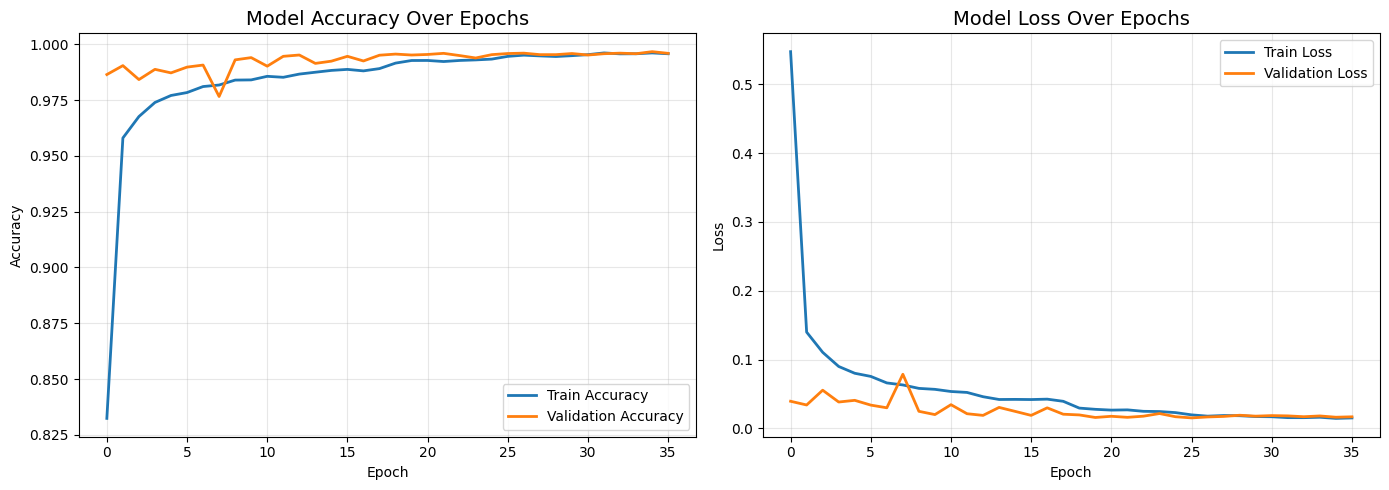


Final Training Accuracy: 0.9957
Final Validation Accuracy: 0.9959
Accuracy Gap (Overfit Indicator): 0.0002
Model shows good generalization with minimal overfitting.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss Over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
print(f"\nFinal Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")
print(f"Accuracy Gap (Overfit Indicator): {abs(train_acc - val_acc):.4f}")
if abs(train_acc - val_acc) < 0.02:
    print("Model shows good generalization with minimal overfitting.")
else:
    print("Warning: Model may be overfitting.")

In [13]:
test_loss, test_acc = model.evaluate(X_test_processed, y_test_cat, verbose=2)
print(f'\nTest Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

predicted_classes = np.argmax(model.predict(X_test_processed), axis=-1)

313/313 - 4s - 12ms/step - accuracy: 0.9968 - loss: 0.0111

Test Accuracy: 0.9968
Test Loss: 0.0111
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step


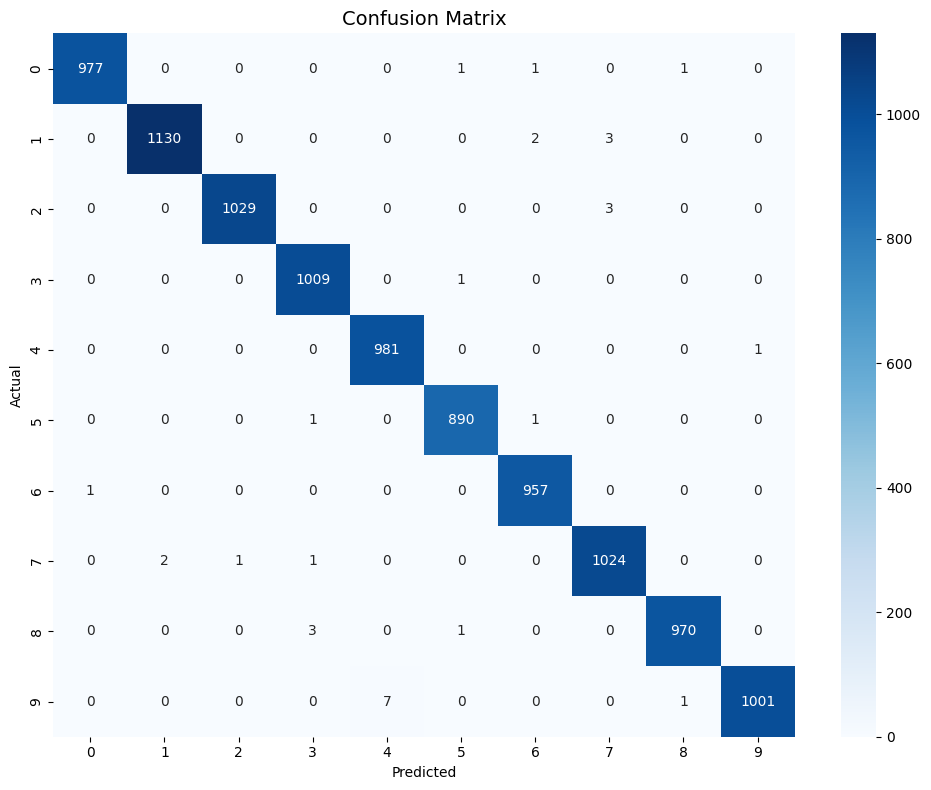


Classification Report:
              precision    recall  f1-score   support

           0     0.9990    0.9969    0.9980       980
           1     0.9982    0.9956    0.9969      1135
           2     0.9990    0.9971    0.9981      1032
           3     0.9951    0.9990    0.9970      1010
           4     0.9929    0.9990    0.9959       982
           5     0.9966    0.9978    0.9972       892
           6     0.9958    0.9990    0.9974       958
           7     0.9942    0.9961    0.9951      1028
           8     0.9979    0.9959    0.9969       974
           9     0.9990    0.9921    0.9955      1009

    accuracy                         0.9968     10000
   macro avg     0.9968    0.9968    0.9968     10000
weighted avg     0.9968    0.9968    0.9968     10000



In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, predicted_classes, digits=4))

Total misclassified: 32 out of 10000


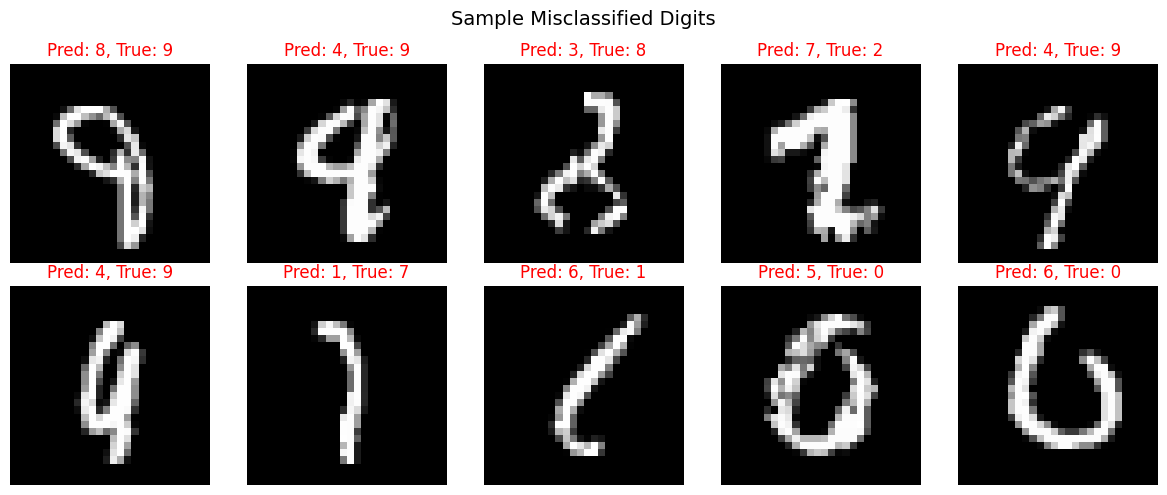

In [15]:
incorrect_indices = np.where(predicted_classes != y_test)[0]
print(f"Total misclassified: {len(incorrect_indices)} out of {len(y_test)}")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    if i < len(incorrect_indices):
        idx = incorrect_indices[i]
        ax.imshow(X_test[idx], cmap='gray')
        ax.set_title(f'Pred: {predicted_classes[idx]}, True: {y_test[idx]}', color='red')
    ax.axis('off')
plt.suptitle('Sample Misclassified Digits', fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
n_samples_pca = 5000
indices = np.random.choice(len(X_train_full), n_samples_pca, replace=False)
X_pca_data = X_train_full[indices].reshape(n_samples_pca, -1).astype('float32') / 255.0
y_pca_labels = y_train_full[indices]

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_pca_data)

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_pca_data)

print(f"\n3D PCA Explained variance: {pca_3d.explained_variance_ratio_}")
print(f"3D PCA Total explained variance: {sum(pca_3d.explained_variance_ratio_):.4f}")
print(f"\n2D PCA Explained variance: {pca_2d.explained_variance_ratio_}")
print(f"2D PCA Total explained variance: {sum(pca_2d.explained_variance_ratio_):.4f}")


3D PCA Explained variance: [0.10000696 0.07149571 0.06229912]
3D PCA Total explained variance: 0.2338

2D PCA Explained variance: [0.10000698 0.07149576]
2D PCA Total explained variance: 0.1715


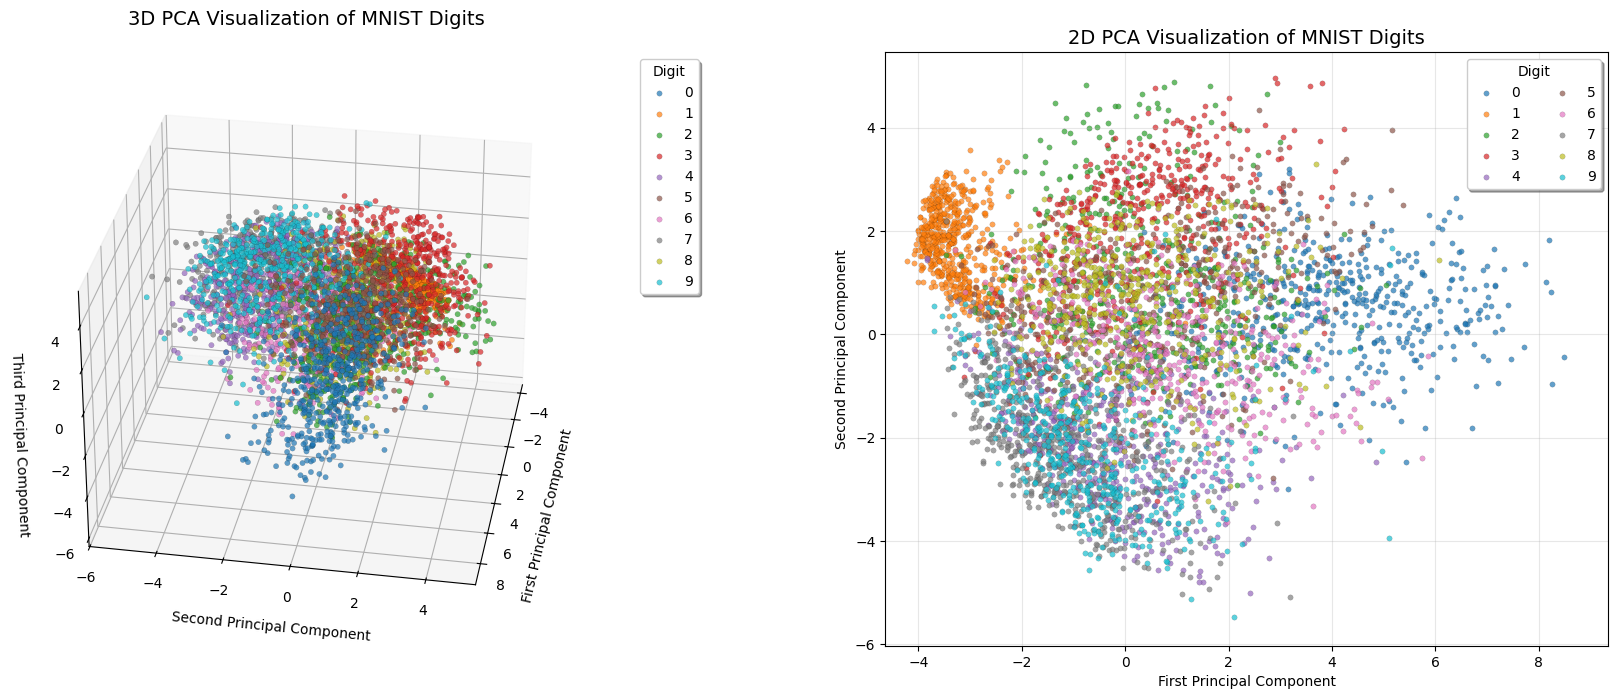


3D PCA: Captured 23.38% of variance
2D PCA: Captured 17.15% of variance


In [26]:
colors = plt.cm.tab10(np.linspace(0, 1, 10))
marker_size = 15

fig = plt.figure(figsize=(18, 7))

ax1 = fig.add_subplot(121, projection='3d')
for digit in range(10):
    mask = y_pca_labels == digit
    ax1.scatter(
        X_pca_3d[mask, 0],
        X_pca_3d[mask, 1],
        X_pca_3d[mask, 2],
        c=[colors[digit]],
        label=str(digit),
        alpha=0.7,
        s=marker_size,
        edgecolors='k',
        linewidths=0.1
    )

ax1.set_xlim([X_pca_3d[:, 0].min() * 1.1, X_pca_3d[:, 0].max() * 1.1])
ax1.set_ylim([X_pca_3d[:, 1].min() * 1.1, X_pca_3d[:, 1].max() * 1.1])
ax1.set_zlim([X_pca_3d[:, 2].min() * 1.1, X_pca_3d[:, 2].max() * 1.1])
ax1.set_xlabel('First Principal Component', fontsize=10, labelpad=8)
ax1.set_ylabel('Second Principal Component', fontsize=10, labelpad=8)
ax1.set_zlabel('Third Principal Component', fontsize=10, labelpad=8)
ax1.set_title('3D PCA Visualization of MNIST Digits', fontsize=14, pad=20)
ax1.view_init(elev=30, azim=10)
ax1.legend(title='Digit', loc='upper left', bbox_to_anchor=(1.05, 1), ncol=1, frameon=True, shadow=True)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(122)
for digit in range(10):
    mask = y_pca_labels == digit
    ax2.scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        c=[colors[digit]],
        label=str(digit),
        alpha=0.7,
        s=marker_size,
        edgecolors='k',
        linewidths=0.1
    )

ax2.set_xlim([X_pca_2d[:, 0].min() * 1.1, X_pca_2d[:, 0].max() * 1.1])
ax2.set_ylim([X_pca_2d[:, 1].min() * 1.1, X_pca_2d[:, 1].max() * 1.1])
ax2.set_xlabel('First Principal Component', fontsize=10)
ax2.set_ylabel('Second Principal Component', fontsize=10)
ax2.set_title('2D PCA Visualization of MNIST Digits', fontsize=14)
ax2.legend(title='Digit', loc='upper right', ncol=2, frameon=True, shadow=True)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n3D PCA: Captured {sum(pca_3d.explained_variance_ratio_)*100:.2f}% of variance")
print(f"2D PCA: Captured {sum(pca_2d.explained_variance_ratio_)*100:.2f}% of variance")

In [ ]:
model.save('Digit_Recognizer.keras')
print("Model saved as 'Digit_Recognizer.keras'")

Model saved as 'Digit_Recognizer_Improved.keras'


In [3]:
from tensorflow.keras.models import load_model
model = load_model('Digit_Recognizer.keras')

In [4]:
import pygame
import numpy as np

pygame.init()

window_size = 560
grid_size = 28
cell_size = window_size // grid_size
sidebar_width = 350

screen = pygame.display.set_mode((window_size + sidebar_width, window_size))
pygame.display.set_caption('MNIST Digit Recognizer')

grid = np.zeros((grid_size, grid_size), dtype=np.uint8)

pygame.font.init()
font_large = pygame.font.SysFont('Arial', 48, bold=True)
font_medium = pygame.font.SysFont('Arial', 24)
font_small = pygame.font.SysFont('Arial', 18)

DARK_BG = (30, 30, 40)
SIDEBAR_BG = (45, 45, 55)
ACCENT_COLOR = (100, 149, 237)
SUCCESS_COLOR = (50, 205, 50)
TEXT_COLOR = (255, 255, 255)
GRID_LINE_COLOR = (60, 60, 70)

def clear_grid():
    global grid
    grid = np.zeros((grid_size, grid_size), dtype=np.uint8)

def draw_grid_lines(screen):
    for i in range(grid_size + 1):
        pygame.draw.line(screen, GRID_LINE_COLOR, (i * cell_size, 0), (i * cell_size, window_size), 1)
        pygame.draw.line(screen, GRID_LINE_COLOR, (0, i * cell_size), (window_size, i * cell_size), 1)

def draw_grid(screen, grid):
    for y in range(grid_size):
        for x in range(grid_size):
            color = (grid[y, x], grid[y, x], grid[y, x])
            pygame.draw.rect(screen, color, pygame.Rect(x * cell_size, y * cell_size, cell_size, cell_size))

def blend_color(current_color, new_color, alpha):
    curr = float(current_color)
    new = float(new_color)
    res = curr + (new - curr) * alpha
    return int(max(0, min(255, res)))

def draw_smooth_brush(grid, x, y, radius, erase=False):
    falloff = radius * 1.3
    for i in range(-radius, radius + 1):
        for j in range(-radius, radius + 1):
            dist = np.sqrt(i**2 + j**2)
            if dist <= falloff:
                grid_x = min(max(x + i, 0), grid_size - 1)
                grid_y = min(max(y + j, 0), grid_size - 1)
                alpha = max(0, 1 - dist / falloff)
                if erase:
                    grid[grid_y, grid_x] = blend_color(grid[grid_y, grid_x], 0, alpha)
                else:
                    grid[grid_y, grid_x] = blend_color(grid[grid_y, grid_x], 255, alpha)

def grid_to_array(grid):
    return grid.flatten().astype('float32') / 255

def get_prediction(array_784):
    prediction = model.predict(array_784.reshape(1, 28, 28, 1), verbose=0)
    return np.argmax(prediction), prediction[0]

def draw_sidebar(screen, predicted_digit, probabilities):
    sidebar_rect = pygame.Rect(window_size, 0, sidebar_width, window_size)
    pygame.draw.rect(screen, SIDEBAR_BG, sidebar_rect)
    pygame.draw.line(screen, ACCENT_COLOR, (window_size, 0), (window_size, window_size), 3)
    
    title = font_medium.render('Digit Recognizer', True, ACCENT_COLOR)
    screen.blit(title, (window_size + 20, 20))
    
    subtitle = font_small.render('CNN Model', True, (150, 150, 150))
    screen.blit(subtitle, (window_size + 20, 50))
    
    if predicted_digit is not None:
        pred_label = font_small.render('Prediction:', True, TEXT_COLOR)
        screen.blit(pred_label, (window_size + 20, 100))
        
        pred_value = font_large.render(str(predicted_digit), True, SUCCESS_COLOR)
        screen.blit(pred_value, (window_size + 20, 125))
        
        conf_label = font_small.render(f'Confidence: {probabilities[predicted_digit]*100:.1f}%', True, TEXT_COLOR)
        screen.blit(conf_label, (window_size + 80, 145))
        
        prob_label = font_small.render('All Probabilities:', True, TEXT_COLOR)
        screen.blit(prob_label, (window_size + 20, 200))
        
        bar_start_y = 230
        bar_width = 200
        bar_height = 25
        
        for i in range(10):
            y_pos = bar_start_y + i * (bar_height + 5)
            
            pygame.draw.rect(screen, (60, 60, 70), (window_size + 50, y_pos, bar_width, bar_height))
            
            fill_width = int(bar_width * probabilities[i])
            color = SUCCESS_COLOR if i == predicted_digit else ACCENT_COLOR
            pygame.draw.rect(screen, color, (window_size + 50, y_pos, fill_width, bar_height))
            
            digit_text = font_small.render(str(i), True, TEXT_COLOR)
            screen.blit(digit_text, (window_size + 25, y_pos + 3))
            
            prob_text = font_small.render(f'{probabilities[i]*100:.1f}%', True, TEXT_COLOR)
            screen.blit(prob_text, (window_size + 260, y_pos + 3))
    
    instructions = [
        'Controls:',
        'Left Click: Draw',
        'Right Click: Erase', 
        'C: Clear Canvas'
    ]
    
    y_start = window_size - 120
    for i, text in enumerate(instructions):
        color = ACCENT_COLOR if i == 0 else (150, 150, 150)
        inst_text = font_small.render(text, True, color)
        screen.blit(inst_text, (window_size + 20, y_start + i * 25))

running = True
drawing = False
erasing = False
radius = 1
predicted_digit = None
probabilities = np.zeros(10)

while running:
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        elif event.type == pygame.MOUSEBUTTONDOWN:
            if event.button == 1 and event.pos[0] < window_size:
                drawing = True
                x, y = event.pos
                grid_x = x // cell_size
                grid_y = y // cell_size
                draw_smooth_brush(grid, grid_x, grid_y, radius)
            elif event.button == 3 and event.pos[0] < window_size:
                erasing = True
                x, y = event.pos
                grid_x = x // cell_size
                grid_y = y // cell_size
                draw_smooth_brush(grid, grid_x, grid_y, radius, erase=True)
        elif event.type == pygame.KEYDOWN:
            if event.key == pygame.K_c:
                clear_grid()
                predicted_digit = None
                probabilities = np.zeros(10)
        elif event.type == pygame.MOUSEBUTTONUP:
            if event.button == 1:
                drawing = False
            elif event.button == 3:
                erasing = False
            array_784 = grid_to_array(grid)
            predicted_digit, probabilities = get_prediction(array_784)
        elif event.type == pygame.MOUSEMOTION:
            if (drawing or erasing) and event.pos[0] < window_size:
                x, y = event.pos
                grid_x = x // cell_size
                grid_y = y // cell_size
                draw_smooth_brush(grid, grid_x, grid_y, radius, erase=erasing)

    screen.fill(DARK_BG)
    draw_grid(screen, grid)
    draw_grid_lines(screen)
    draw_sidebar(screen, predicted_digit, probabilities)
    pygame.display.flip()

pygame.quit()

c:\Users\paaar\AppData\Local\Programs\Python\Python313\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


pygame 2.6.1 (SDL 2.28.4, Python 3.13.5)
Hello from the pygame community. https://www.pygame.org/contribute.html
